Ejercicio

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
datos = pd.read_csv('medical_insurance.csv')
datos.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [4]:
datos.describe()

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


In [9]:
# Verificar si hay valores faltantes

datos.isna().sum()

person_id                          0
age                                0
sex                                0
region                             0
urban_rural                        0
income                             0
education                          0
marital_status                     0
employment_status                  0
household_size                     0
dependents                         0
bmi                                0
smoker                             0
alcohol_freq                   30083
visits_last_year                   0
hospitalizations_last_3yrs         0
days_hospitalized_last_3yrs        0
medication_count                   0
systolic_bp                        0
diastolic_bp                       0
ldl                                0
hba1c                              0
plan_type                          0
network_tier                       0
deductible                         0
copay                              0
policy_term_years                  0
p

In [11]:
# Verificar si hay valores duplicados

# #Resumen de las variables discretas
print(datos.describe(include='object'))

           sex  region urban_rural  education marital_status  \
count   100000  100000      100000     100000         100000   
unique       3       5           3          6              4   
top     Female   South       Urban  Bachelors        Married   
freq     49193   28029       60019      27996          53252   

       employment_status  smoker alcohol_freq plan_type network_tier  
count             100000  100000        69917    100000       100000  
unique                 4       3            3         4            4  
top             Employed   Never   Occasional       PPO       Silver  
freq               55269   69709        45078     35167        40177  


In [20]:
datos["network_tier"].value_counts()

network_tier
Silver      40177
Bronze      29932
Gold        19882
Platinum    10009
Name: count, dtype: int64

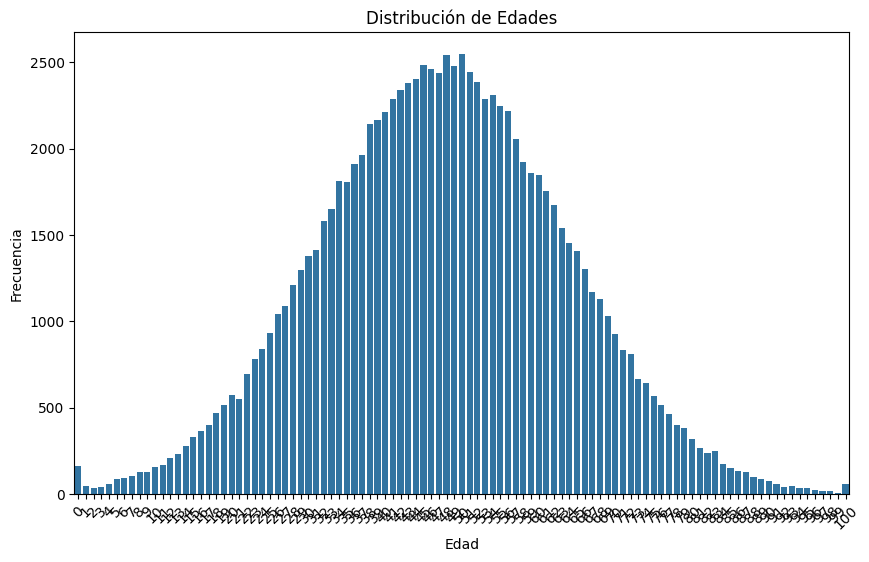

In [25]:
plt.figure(figsize=(10, 6))
sns.countplot(x='age', data=datos)
plt.title('Distribución de Edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

In [27]:
list(datos.describe(include='object').columns)

['sex',
 'region',
 'urban_rural',
 'education',
 'marital_status',
 'employment_status',
 'smoker',
 'alcohol_freq',
 'plan_type',
 'network_tier']

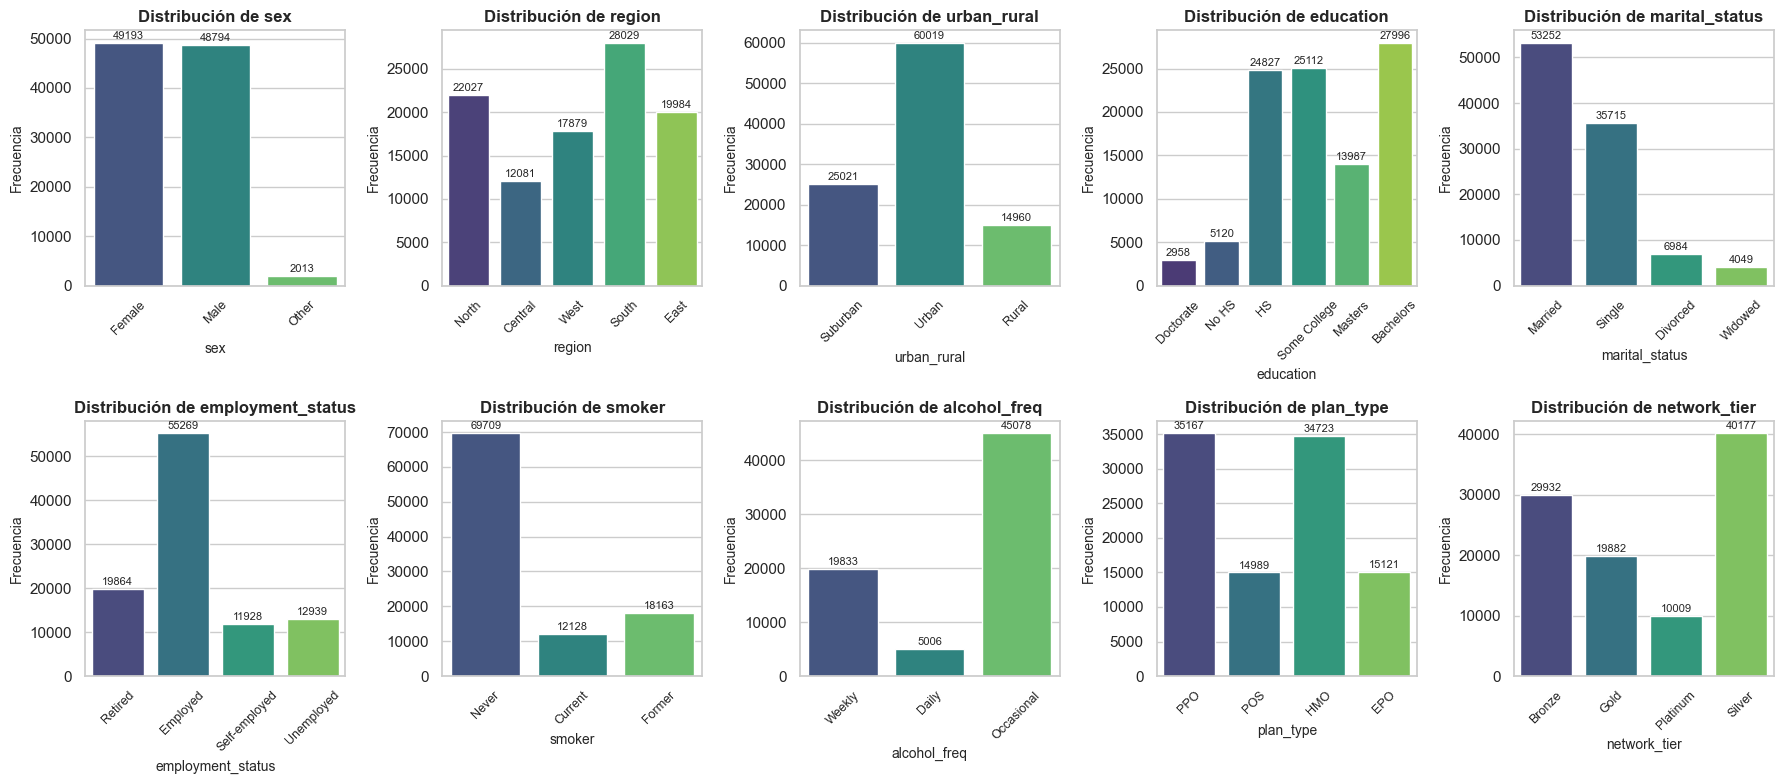

In [41]:
# 1. Configurar un estilo general más bonito
sns.set_theme(style="whitegrid")

# Obtener las columnas categóricas (es más seguro usar select_dtypes)
columnas_cat = datos.select_dtypes(include=['object', 'category']).columns

# 2. Crear la figura y los ejes UNA sola vez. 
# Aumenté un poco el alto (de 5 a 8) para que los textos a 45 grados tengan espacio.
figure, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten() # Aplanar para iterar fácilmente

# 3. Iterar correctamente sobre las columnas y los ejes
for i, column in enumerate(columnas_cat):
    # Por si tienes más de 10 columnas, evitamos un error
    if i >= len(axes): 
        break
        
    ax = axes[i]
    
    # Crear el gráfico. 
    # Añadimos 'hue' y una paleta de colores para que cada barra se vea distinta.
    sns.countplot(x=column, data=datos, ax=ax, hue=column, legend=False, palette='viridis')
    
    # 4. Ajustes estéticos individuales para cada gráfica
    ax.set_title(f'Distribución de {column}', fontsize=12, fontweight='bold')
    ax.set_xlabel(column, fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    
    # (Opcional) Agregar el número exacto encima de cada barra
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 5), textcoords='offset points', fontsize=8)

# 5. Ocultar los gráficos sobrantes si tienes menos de 10 columnas categóricas
for j in range(i + 1, len(axes)):
    figure.delaxes(axes[j])

# 6. Mostrar todo ordenado
plt.tight_layout()
plt.show()

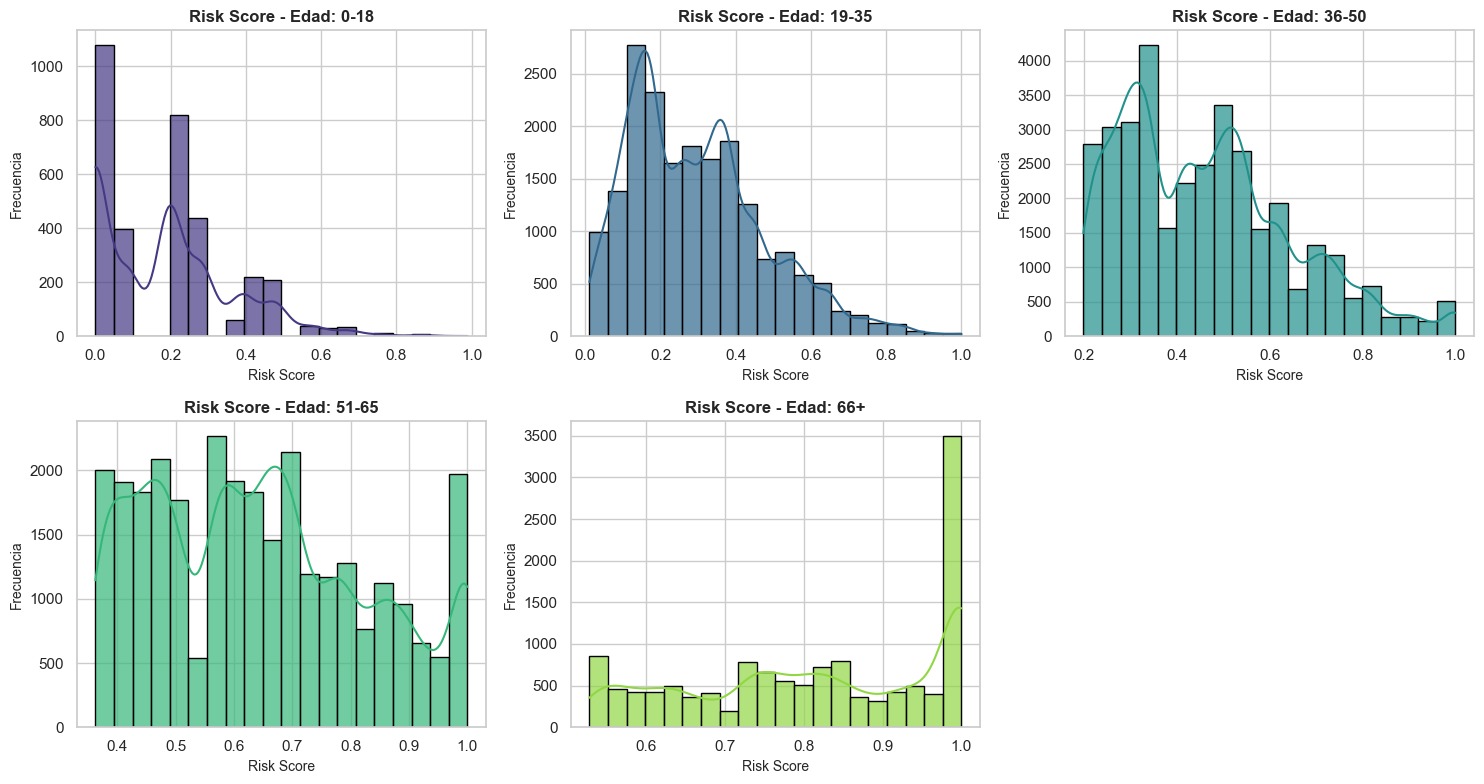

In [42]:
# 1. Aplicar estilo general
sns.set_theme(style="whitegrid")

# 2. Tu código para crear los grupos de edad
datos["g-edad"] = pd.cut(datos["age"], bins=[0, 18, 35, 50, 65, 100], labels=['0-18', '19-35', '36-50', '51-65', '66+'])

# 3. Crear figura y ejes. 
# Aumenté ligeramente el tamaño a (15, 8) para que los 6 gráficos tengan buen espacio.
figure, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten() # Aplanamos el arreglo de ejes para iterar con un solo ciclo 'for'

# Obtener la lista de categorías
grupos_edad = ['0-18', '19-35', '36-50', '51-65', '66+']
colores = sns.color_palette("viridis", len(grupos_edad)) # Generar colores bonitos

# 4. Iterar sobre cada grupo y dibujar su histograma
for i, grupo in enumerate(grupos_edad):
    ax = axes[i]
    
    # Filtrar los datos solo para este grupo de edad
    datos_grupo = datos[datos["g-edad"] == grupo]
    
    # Dibujar el histograma
    # bins=20 ajusta la cantidad de barras, kde=True dibuja la curva de tendencia
    sns.histplot(data=datos_grupo, x="risk_score", ax=ax, bins=20, 
                 color=colores[i], kde=True, edgecolor='black', alpha=0.7)
    
    # Ajustes estéticos para cada subplot
    ax.set_title(f'Risk Score - Edad: {grupo}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Risk Score', fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)

# 5. Eliminar el 6to recuadro que sobra (índice 5), ya que solo hay 5 grupos
figure.delaxes(axes[5])

# 6. Ajustar el espaciado y mostrar
plt.tight_layout()
plt.show()

In [45]:
datos.groupby(["g-edad", "marital_status"])["person_id"].count().unstack().fillna(0)

C:\Users\gusta\AppData\Local\Temp\ipykernel_8592\382212248.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  datos.groupby(["g-edad", "marital_status"])["person_id"].count().unstack().fillna(0)


marital_status,Divorced,Married,Single,Widowed
g-edad,,,,
0-18,227,1803,1168,151
19-35,1345,10205,6834,804
36-50,2447,18335,12593,1378
51-65,2022,15738,10475,1181
66+,936,7073,4587,533


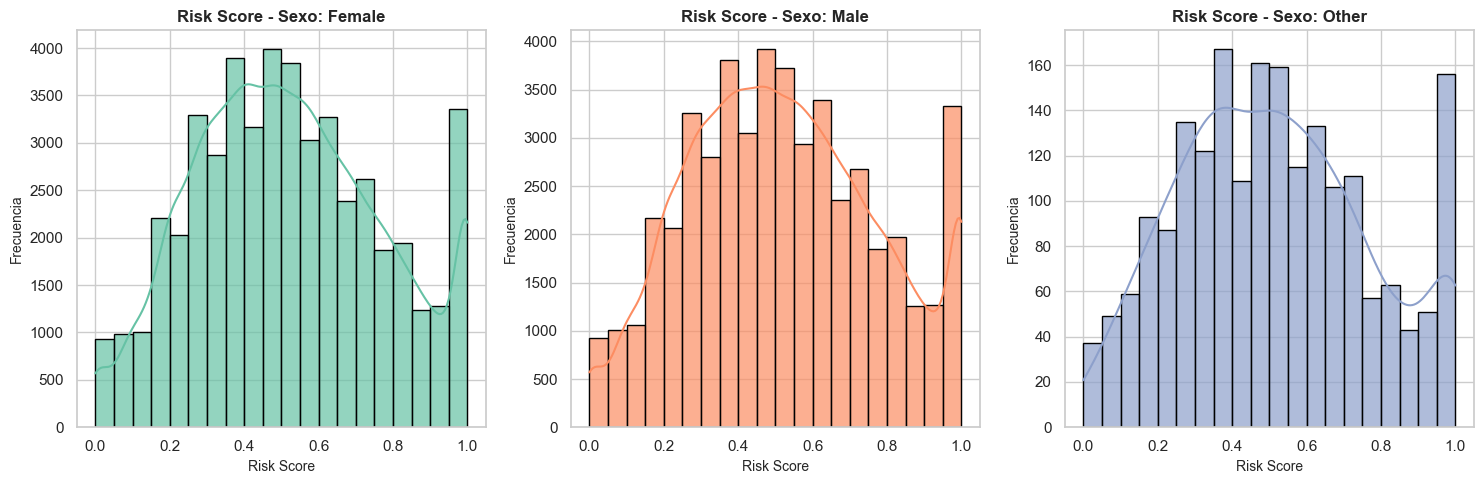

In [46]:
# 1. Aplicar estilo general
sns.set_theme(style="whitegrid")

# 2. Extraer los 3 sexos de tu dataframe
sexos = datos["sex"].dropna().unique()

# 3. Crear figura y ejes explícitamente para 1 fila y 3 columnas
# Un ancho de 15 y alto de 5 es ideal para 3 gráficas lado a lado
figure, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

# Usar una paleta de colores para las 3 categorías
colores = sns.color_palette("Set2", 3)

# 4. Iterar sobre las 3 categorías
for i, sexo in enumerate(sexos):
    ax = axes[i]
    
    # Filtrar los datos solo para el sexo actual en el ciclo
    datos_grupo = datos[datos["sex"] == sexo]
    
    # Dibujar el histograma de 'risk_score'
    sns.histplot(data=datos_grupo, x="risk_score", ax=ax, bins=20, 
                 color=colores[i], kde=True, edgecolor='black', alpha=0.7)
    
    # Ajustes estéticos para que se vea muy limpio
    ax.set_title(f'Risk Score - Sexo: {sexo}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Risk Score', fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)

# 5. Ajustar márgenes para que no choquen los textos y mostrar
plt.tight_layout()
plt.show()

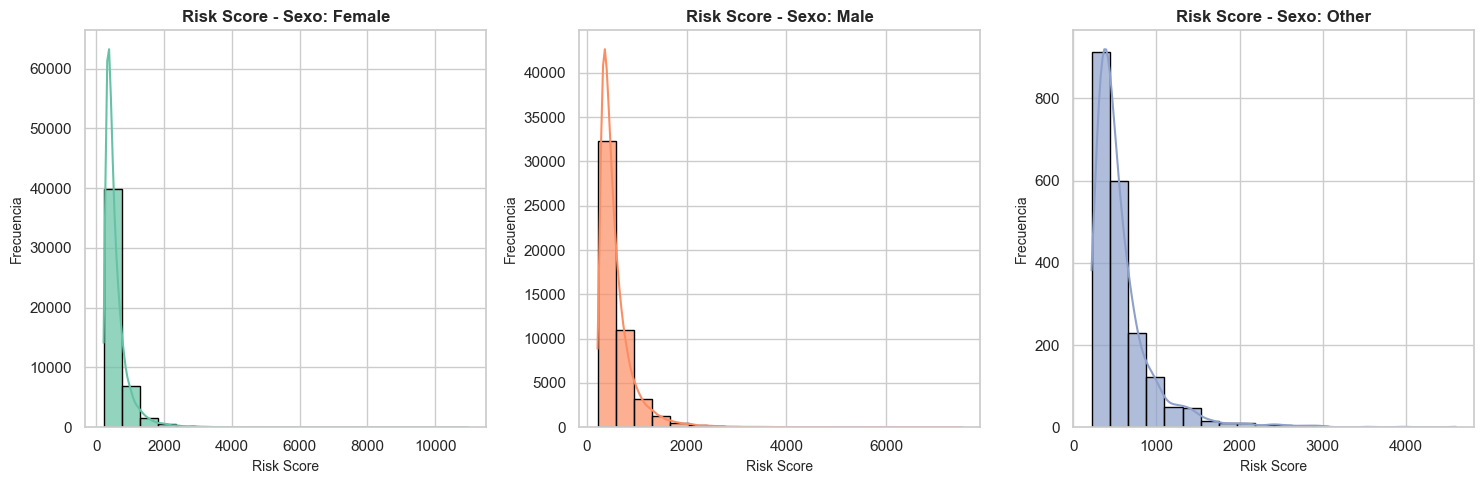

In [49]:
# 1. Aplicar estilo general
sns.set_theme(style="whitegrid")

# 2. Extraer los 3 sexos de tu dataframe
sexos = datos["sex"].dropna().unique()

# 3. Crear figura y ejes explícitamente para 1 fila y 3 columnas
# Un ancho de 15 y alto de 5 es ideal para 3 gráficas lado a lado
figure, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

# Usar una paleta de colores para las 3 categorías
colores = sns.color_palette("Set2", 3)

# 4. Iterar sobre las 3 categorías
for i, sexo in enumerate(sexos):
    ax = axes[i]
    
    # Filtrar los datos solo para el sexo actual en el ciclo
    datos_grupo = datos[datos["sex"] == sexo]
    
    # Dibujar el histograma de 'risk_score'
    sns.histplot(data=datos_grupo, x="annual_premium", ax=ax, bins=20, 
                 color=colores[i], kde=True, edgecolor='black', alpha=0.7)
    
    # Ajustes estéticos para que se vea muy limpio
    ax.set_title(f'Risk Score - Sexo: {sexo}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Risk Score', fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)

# 5. Ajustar márgenes para que no choquen los textos y mostrar
plt.tight_layout()
plt.show()

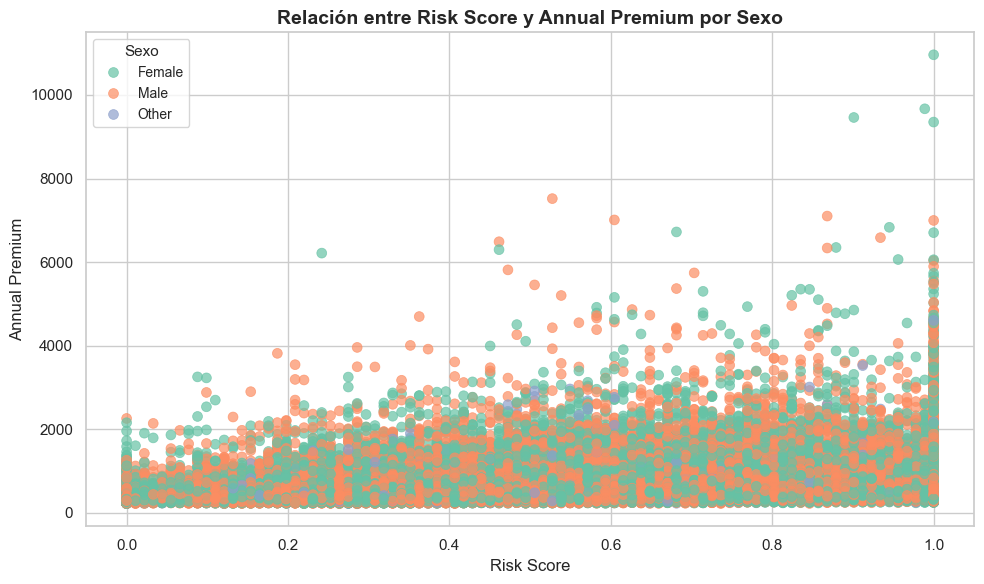

In [50]:
# 1. Aplicar el estilo general
sns.set_theme(style="whitegrid")

# 2. Crear la figura con un buen tamaño
plt.figure(figsize=(10, 6))

# 3. Crear el scatterplot
# x = Eje horizontal, y = Eje vertical, hue = Variable para colorear
sns.scatterplot(
    data=datos, 
    x="risk_score", 
    y="annual_premium", 
    hue="sex", 
    palette="Set2",   # Usamos la misma paleta bonita de 3 colores
    alpha=0.7,        # Transparencia para ver puntos superpuestos
    edgecolor=None,   # Quitar bordes de los puntos para que se vea más limpio
    s=50              # Tamaño de los puntos (puedes aumentarlo o disminuirlo)
)

# 4. Añadir títulos y etiquetas para que sea fácil de entender
plt.title('Relación entre Risk Score y Annual Premium por Sexo', fontsize=14, fontweight='bold')
plt.xlabel('Risk Score', fontsize=12)
plt.ylabel('Annual Premium', fontsize=12)

# 5. Ajustar la leyenda
plt.legend(title='Sexo', title_fontsize='11', fontsize='10', loc='best')

# 6. Mostrar el gráfico
plt.tight_layout()
plt.show()

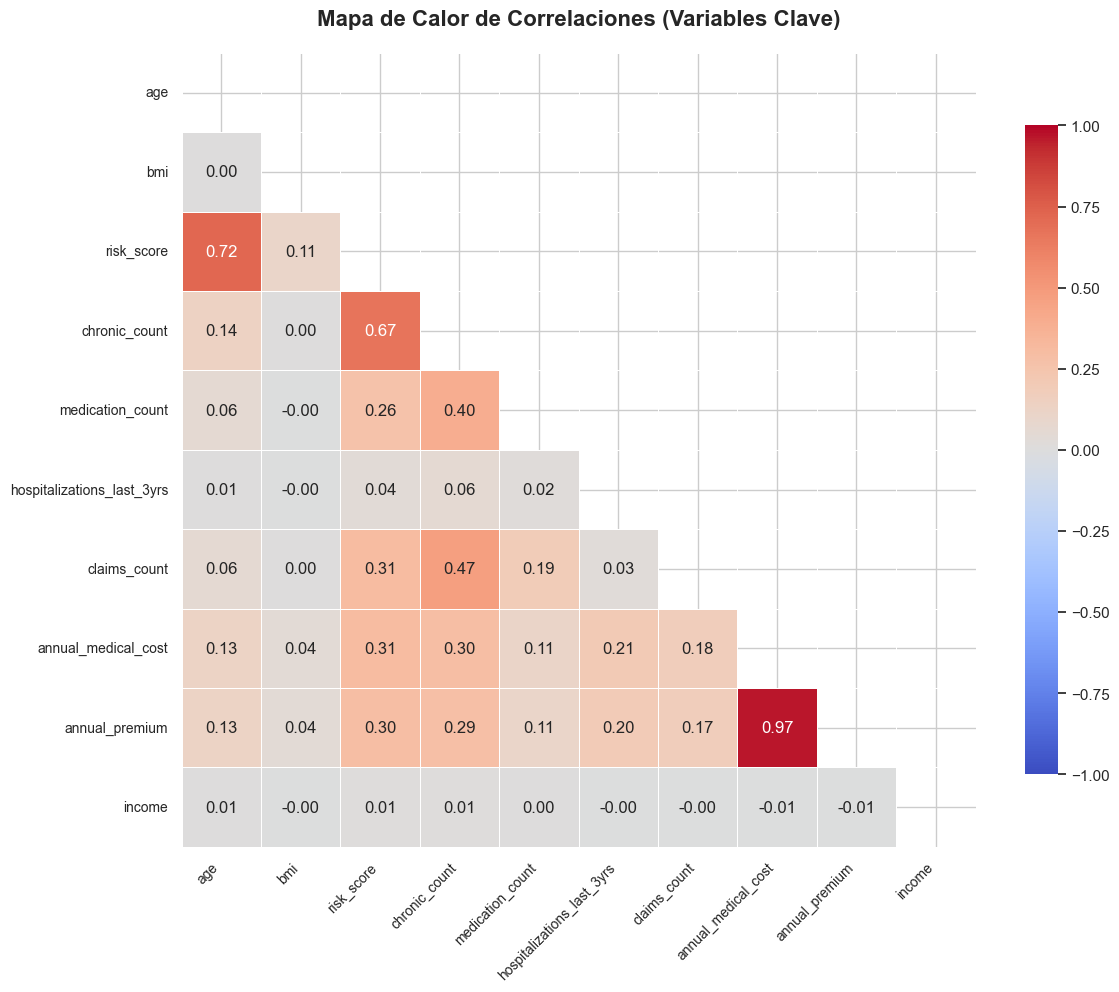

In [55]:
# 1. Seleccionar las columnas numéricas más relevantes para el análisis
columnas_clave = [
    'age',                         # Edad
    'bmi',                         # Índice de Masa Corporal
    'risk_score',                  # Puntuación de riesgo
    'chronic_count',               # Número de enfermedades crónicas
    'medication_count',            # Cantidad de medicamentos
    'hospitalizations_last_3yrs',  # Hospitalizaciones
    'claims_count',                # Cantidad de reclamos
    'annual_medical_cost',         # Costo médico anual
    'annual_premium',              # Prima anual a pagar
    'income'                       # Ingresos
]

# 2. Calcular la matriz de correlación (solo con estas columnas)
correlacion = datos[columnas_clave].corr()

# 3. Crear una máscara para ocultar el triángulo superior (información duplicada)
mask = np.triu(np.ones_like(correlacion, dtype=bool))

# 4. Configurar la figura (tamaño amplio para que se lean bien los números)
plt.figure(figsize=(12, 10))

# 5. Dibujar el heatmap
sns.heatmap(
    correlacion, 
    mask=mask,                  # Aplicar la máscara
    cmap='coolwarm',            # Paleta de colores: azul (negativa), rojo (positiva)
    vmax=1.0, vmin=-1.0,        # Rango de la correlación de -1 a 1
    center=0,                   # Centrar los colores en 0
    annot=True,                 # Mostrar los números de correlación
    fmt='.2f',                  # Redondear a 2 decimales
    square=True,                # Cajas cuadradas
    linewidths=.5,              # Separación entre las cajitas
    cbar_kws={"shrink": .8}     # Achicar un poco la barra de color lateral
)

# 6. Ajustes de diseño
plt.title('Mapa de Calor de Correlaciones (Variables Clave)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

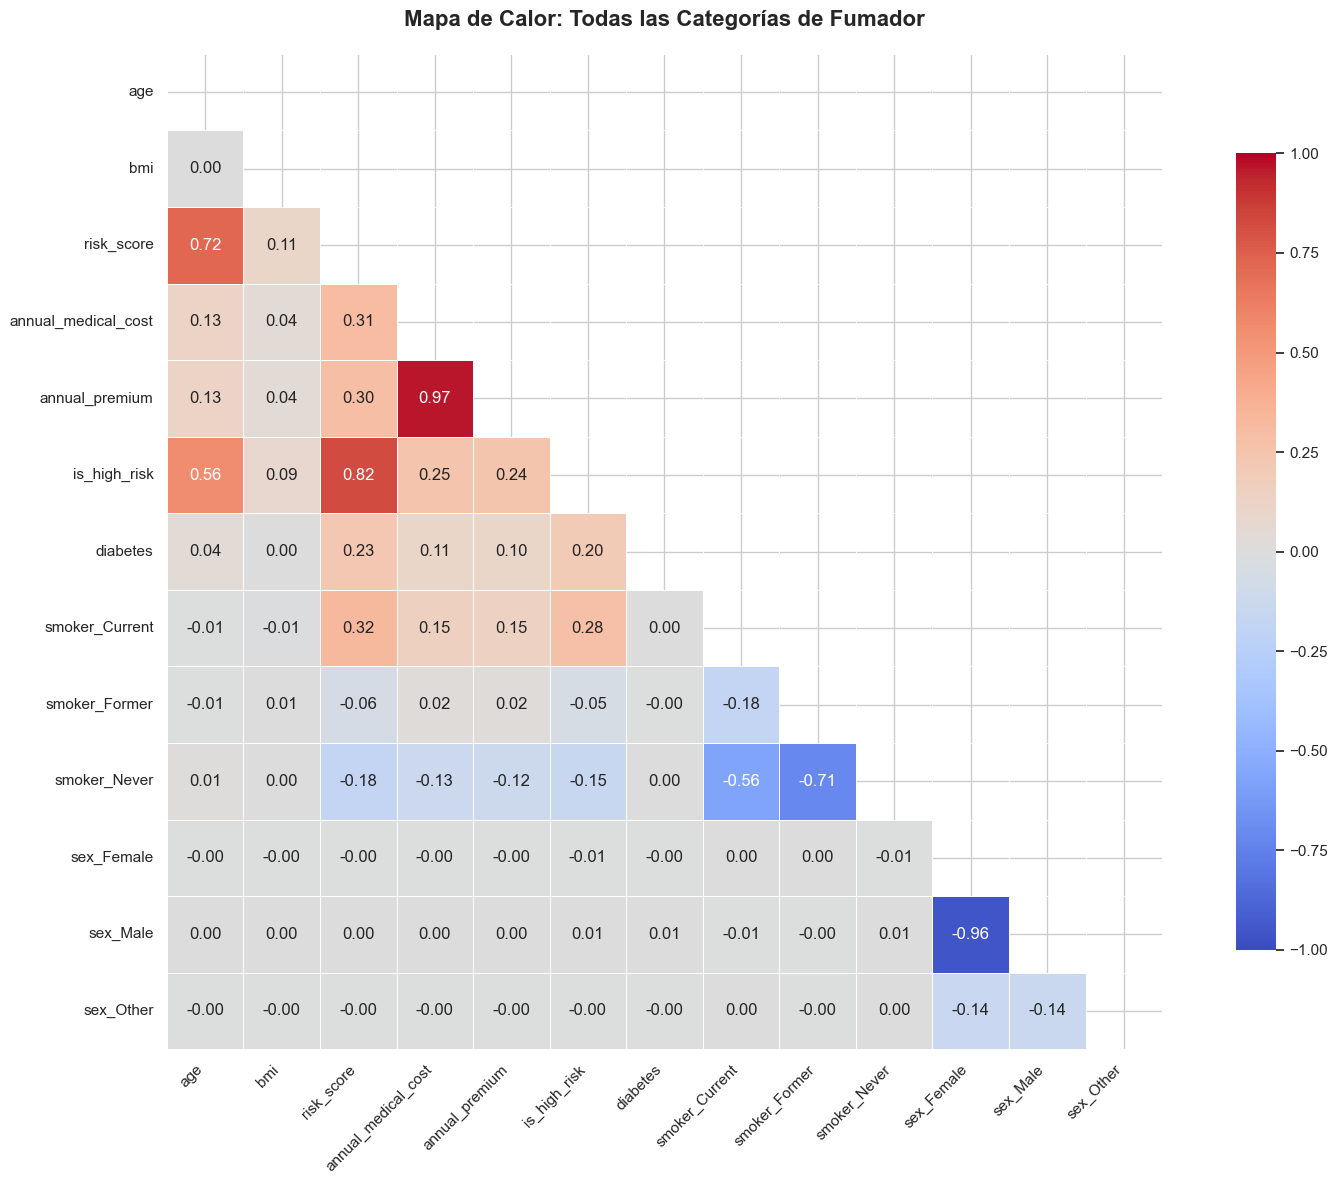

In [57]:
# 1. Aplicar estilo general
sns.set_theme(style="whitegrid")

# 2. Seleccionamos las variables clave (incluyendo tus categóricas)
columnas_mixtas = [
    'age', 
    'bmi', 
    'risk_score', 
    'annual_medical_cost', 
    'annual_premium',
    'smoker',        # Tu columna de 3 categorías
    'sex',           
    'is_high_risk',  
    'diabetes'       
]

# Creamos una copia de esos datos
datos_heat = datos[columnas_mixtas].copy()

# 3. EL CAMBIO CLAVE: Transformar a numéricas manteniendo TODAS las categorías
# Usamos drop_first=False (que es el valor por defecto)
datos_heat_num = pd.get_dummies(datos_heat, drop_first=False)

# 4. Calcular la matriz de correlación
correlacion_mixta = datos_heat_num.corr()

# 5. Crear la máscara para ocultar la mitad superior repetida
mask = np.triu(np.ones_like(correlacion_mixta, dtype=bool))

# 6. Configurar la figura (le di un poco más de alto/ancho por las nuevas columnas)
plt.figure(figsize=(16, 12))

# 7. Dibujar el heatmap
sns.heatmap(
    correlacion_mixta, 
    mask=mask, 
    cmap='coolwarm', 
    vmax=1.0, vmin=-1.0, 
    center=0, 
    annot=True, 
    fmt='.2f', 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8}
)

# 8. Ajustes de texto y diseño
plt.title('Mapa de Calor: Todas las Categorías de Fumador', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

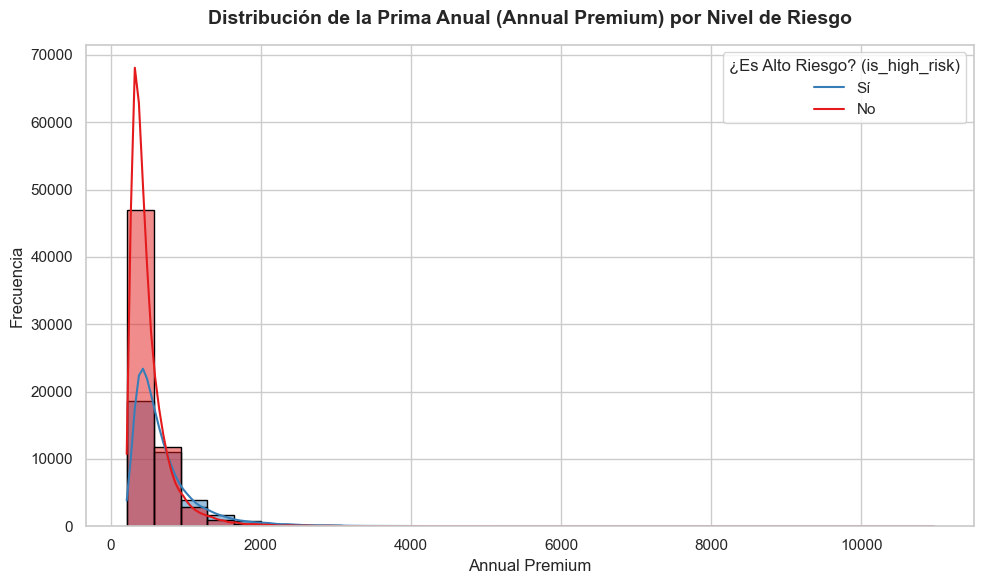

In [58]:
# 1. Aplicar estilo general
sns.set_theme(style="whitegrid")

# 2. Configurar el tamaño de la figura
plt.figure(figsize=(10, 6))

# 3. Dibujar el histograma
# Al usar 'hue', Seaborn separa automáticamente los datos y pinta un color para cada categoría
sns.histplot(
    data=datos, 
    x="annual_premium", 
    hue="is_high_risk", 
    bins=30,               # Cantidad de agrupaciones/barras
    kde=True,              # Agrega la línea de tendencia de la distribución
    palette="Set1",        # Usamos colores contrastantes (rojo y azul por defecto)
    alpha=0.5,             # Transparencia al 50% para ver donde se cruzan
    edgecolor='black'      # Borde negro para definir mejor las barras
)

# 4. Ajustes estéticos y títulos
plt.title('Distribución de la Prima Anual (Annual Premium) por Nivel de Riesgo', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Annual Premium', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

# Opcional: Ajustar el título de la leyenda si es necesario
plt.legend(title='¿Es Alto Riesgo? (is_high_risk)', labels=['Sí', 'No'])

# 5. Ajustar márgenes y mostrar
plt.tight_layout()
plt.show()

In [70]:
import plotly.express as px
import pandas as pd

# 1. Crear el histograma superpuesto con Plotly Express
fig = px.histogram(
    datos, 
    x="annual_premium", 
    color="network_tier",     
    barmode="overlay",       # Escala de densidad restaurada
    nbins=50,                 
    opacity=0.6,              
    color_discrete_sequence=px.colors.qualitative.Set2 
)

# 2. Calcular la media de 'annual_premium' para cada 'network_tier'
medias = datos.groupby("network_tier")["annual_premium"].mean()

# Extraer la paleta de colores para que las líneas coincidan con las barras
colores = px.colors.qualitative.Set2

# 3. Agregar una línea vertical por cada media calculada
for i, (tier, media) in enumerate(medias.items()):
    fig.add_vline(
        x=media, 
        line_dash="dash",                  # Estilo de línea punteada
        line_color=colores[i % len(colores)], # Asignar el mismo color del Tier
        line_width=2,
        annotation_text=f"Media {tier}: {media:.0f}", # Texto descriptivo con el valor
        annotation_position="top right",   # Posición del texto
        annotation_font_color=colores[i % len(colores)]
    )

# 4. Ajustes estéticos y de diseño
fig.update_layout(
    title={
        'text': "Densidad de Annual Premium por Nivel de Red (Tier)",
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(size=18, color="black", family="Arial Black")
    },
    xaxis_title="Annual Premium",
    yaxis_title="Densidad",
    legend_title="Tier",
    template="plotly_white",  
    hovermode="x unified"     
)

# 5. Mostrar la gráfica
fig.show()

In [64]:
datos["network_tier"].value_counts()

network_tier
Silver      40177
Bronze      29932
Gold        19882
Platinum    10009
Name: count, dtype: int64

In [63]:
datos.groupby("network_tier")["annual_premium"].mean()

network_tier
Bronze      501.196745
Gold        644.930749
Platinum    733.750983
Silver      574.048741
Name: annual_premium, dtype: float64

In [66]:
datos["plan_type"].value_counts()

plan_type
PPO    35167
HMO    34723
EPO    15121
POS    14989
Name: count, dtype: int64

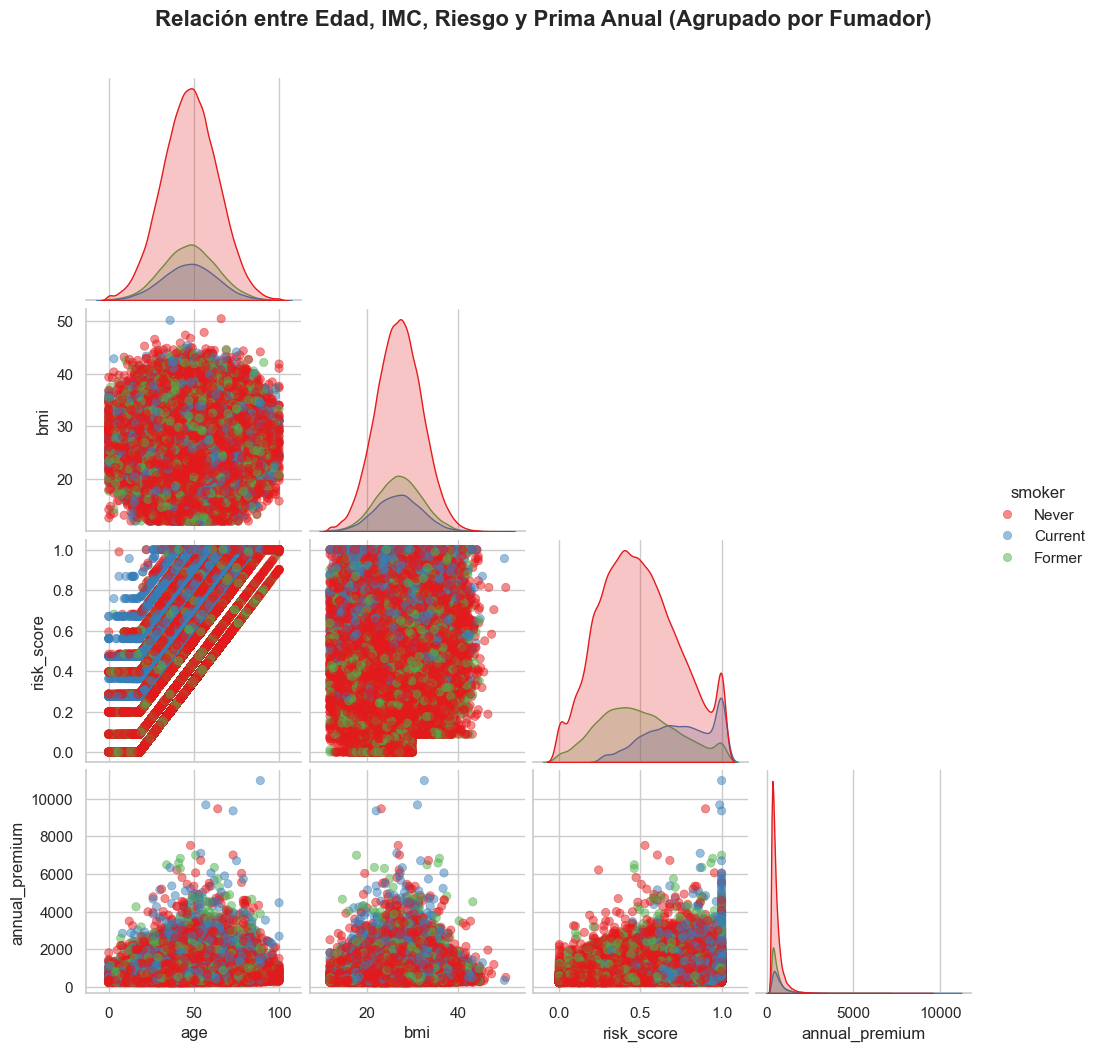

In [74]:
# 1. Aplicar el estilo general
sns.set_theme(style="whitegrid")

# 2. Seleccionar un subconjunto estratégico de variables
columnas_pairplot = [
    'age',              # Edad
    'bmi',              # IMC
    'risk_score',       # Puntuación de riesgo
    'annual_premium',   # Prima anual
    'smoker'            # Variable categórica para dar color
]

# Crear un sub-dataframe solo con estas columnas
datos_subset = datos[columnas_pairplot]

# 3. Generar el Pairplot
grafico = sns.pairplot(
    data=datos_subset,
    hue="smoker",               # Colorea los puntos dependiendo si fuma o no
    palette="Set1",             # Paleta de colores fuerte y contrastante
    plot_kws={'alpha': 0.5, 'edgecolor': None},  # Transparencia y sin bordes en los puntos
    diag_kind="kde",            # En la diagonal mostrará las curvas de densidad
    corner=True                 # Oculta la parte superior derecha para evitar duplicados
)

# 4. Ajustar el título principal
# y=1.05 empuja el título un poco hacia arriba para que no choque con las gráficas
grafico.fig.suptitle(
    'Relación entre Edad, IMC, Riesgo y Prima Anual (Agrupado por Fumador)', 
    y=1.05, 
    fontsize=16, 
    fontweight='bold'
)

# 5. Mostrar la figura
plt.show()

C:\Users\gusta\AppData\Local\Temp\ipykernel_8592\4177852663.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


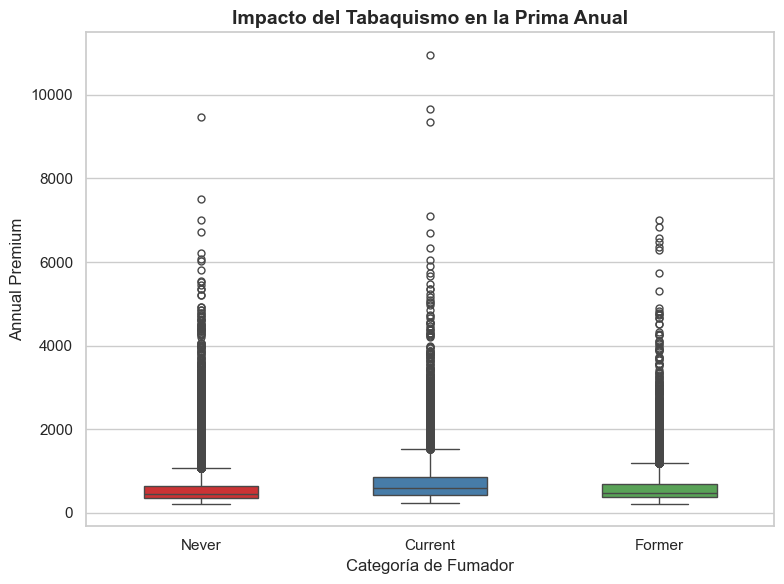

In [75]:
# Configurar estilo
sns.set_theme(style="whitegrid")

# Crear figura
plt.figure(figsize=(8, 6))

# Dibujar el boxplot
sns.boxplot(
    data=datos, 
    x="smoker", 
    y="annual_premium", 
    palette="Set1",
    width=0.5,           # Hace las cajas un poco más delgadas y elegantes
    fliersize=5          # Tamaño de los puntos atípicos (outliers)
)

# Ajustes estéticos
plt.title('Impacto del Tabaquismo en la Prima Anual', fontsize=14, fontweight='bold')
plt.xlabel('Categoría de Fumador', fontsize=12)
plt.ylabel('Annual Premium', fontsize=12)

plt.tight_layout()
plt.show()

C:\Users\gusta\AppData\Local\Temp\ipykernel_8592\4230708378.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


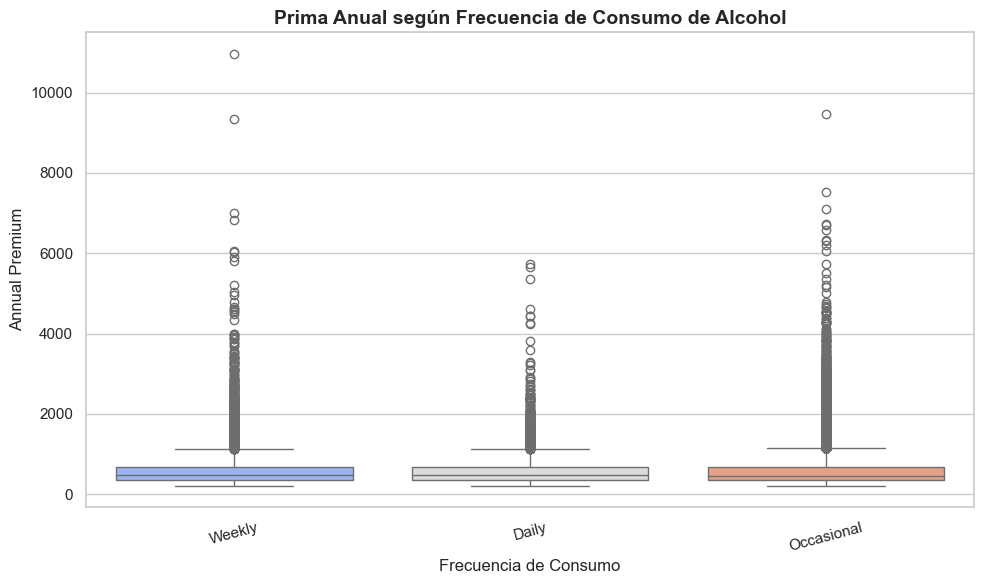

In [76]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Ordenar lógicamente las categorías si es necesario (opcional, ajusta según tus datos)
# orden_alcohol = ['Never', 'Rarely', 'Sometimes', 'Frequently']

sns.boxplot(
    data=datos, 
    x="alcohol_freq", 
    y="annual_premium", 
    palette="coolwarm",
    # order=orden_alcohol  # Descomenta esto si quieres forzar un orden específico
)

plt.title('Prima Anual según Frecuencia de Consumo de Alcohol', fontsize=14, fontweight='bold')
plt.xlabel('Frecuencia de Consumo', fontsize=12)
plt.ylabel('Annual Premium', fontsize=12)

# Rotar etiquetas por si los textos son largos
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

C:\Users\gusta\AppData\Local\Temp\ipykernel_8592\2216874096.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


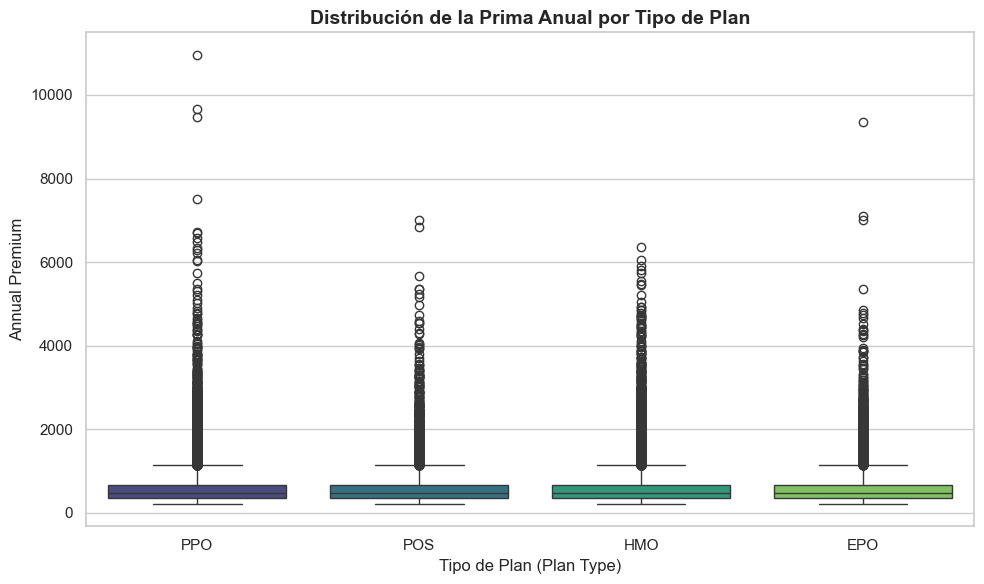

In [77]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=datos, 
    x="plan_type", 
    y="annual_premium", 
    palette="viridis"
)

plt.title('Distribución de la Prima Anual por Tipo de Plan', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Plan (Plan Type)', fontsize=12)
plt.ylabel('Annual Premium', fontsize=12)

plt.tight_layout()
plt.show()

C:\Users\gusta\AppData\Local\Temp\ipykernel_8592\2002444977.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


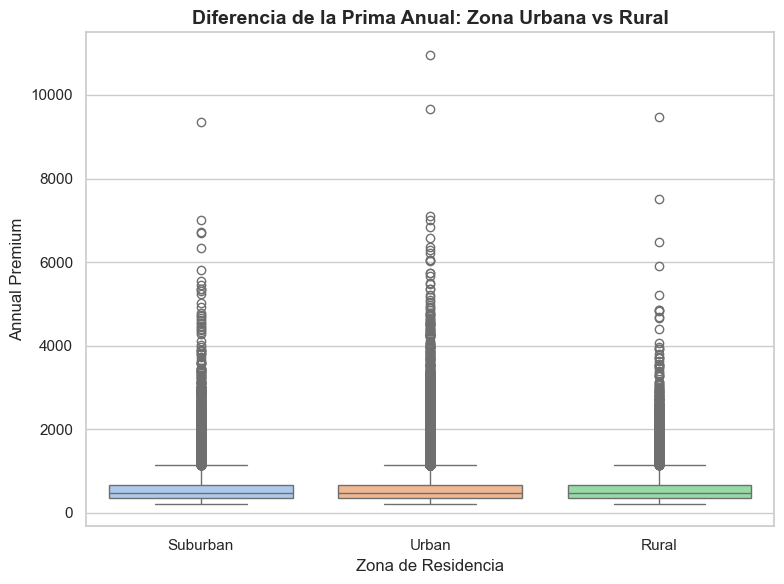

In [78]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=datos, 
    x="urban_rural", 
    y="annual_premium", 
    palette="pastel"
)

plt.title('Diferencia de la Prima Anual: Zona Urbana vs Rural', fontsize=14, fontweight='bold')
plt.xlabel('Zona de Residencia', fontsize=12)
plt.ylabel('Annual Premium', fontsize=12)

plt.tight_layout()
plt.show()